## Data Preparation Pipeline

## Imports & Config

In [ ]:
import os, json, shutil, random, re, csv
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DRYWALL_ROOT = Path("../dataset/Drywall-Join-Detect")
CRACKS_ROOT = Path("../dataset/Cracks")
OUT = Path("../dataset/processed")

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

for ds in ["drywall", "cracks"]:
    (OUT / ds / "images").mkdir(parents=True, exist_ok=True)
    (OUT / ds / "masks").mkdir(parents=True, exist_ok=True)

print(f"Output root : {OUT}")
print(f"Seed        : {SEED}")
print(f"Split       : {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")


Output root : ..\dataset\processed
Seed        : 42
Split       : 0.7/0.15/0.15


## Raw Inventory

In [ ]:
def count_imgs(folder):
    p = Path(folder)
    return (
        sum(1 for f in p.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png"))
        if p.exists()
        else 0
    )


def load_coco(path):
    with open(path) as f:
        return json.load(f)


dw_train_n = count_imgs(DRYWALL_ROOT / "train" / "images")
dw_valid_n = count_imgs(DRYWALL_ROOT / "valid" / "images")
ck_train_n = count_imgs(CRACKS_ROOT / "train")
ck_valid_n = count_imgs(CRACKS_ROOT / "valid")
ck_test_n = count_imgs(CRACKS_ROOT / "test")

ck_train_coco = load_coco(CRACKS_ROOT / "train" / "_annotations.coco.json")
ck_valid_coco = load_coco(CRACKS_ROOT / "valid" / "_annotations.coco.json")
ck_test_coco = load_coco(CRACKS_ROOT / "test" / "_annotations.coco.json")

print(f"{'Split':<22} {'Images':>8} {'Annotations':>12}")
print("-" * 44)
print(f"{'Drywall / train':<22} {dw_train_n:>8} {'YOLO bbox':>12}")
print(f"{'Drywall / valid':<22} {dw_valid_n:>8} {'YOLO bbox':>12}")
print(
    f"{'Cracks  / train':<22} {ck_train_n:>8} {len(ck_train_coco['annotations']):>12}"
)
print(
    f"{'Cracks  / valid':<22} {ck_valid_n:>8} {len(ck_valid_coco['annotations']):>12}"
)
print(f"{'Cracks  / test':<22}  {ck_test_n:>8} {len(ck_test_coco['annotations']):>12}")
print(f"\nTotal raw: {dw_train_n + dw_valid_n + ck_train_n + ck_valid_n + ck_test_n}")


Split                    Images  Annotations
--------------------------------------------
Drywall / train             820    YOLO bbox
Drywall / valid             202    YOLO bbox
Cracks  / train            5164         8133
Cracks  / valid             201          372
Cracks  / test                 4            6

Total raw: 6391


## Deduplication
Roboflow augmented copies carry `.rf.<hash>` in the filename. Remove them to prevent train/val leakage.

In [ ]:
RF_PAT = re.compile(r"(.+)\.rf\.[a-f0-9]+(\.[a-zA-Z]+)$")


def deduplicate(folder):
    originals, aug_map = [], defaultdict(list)
    for f in sorted(Path(folder).iterdir()):
        if f.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue
        m = RF_PAT.match(f.name)
        if m:
            aug_map[m.group(1)].append(f)
        else:
            originals.append(f)

    canonical = list(originals)
    fname_map = {p.name: p for p in originals}
    for base, variants in aug_map.items():
        if not any(p.stem == base for p in originals):
            canonical.append(variants[0])
        for v in variants:
            fname_map.setdefault(v.name, variants[0])
    return canonical, fname_map


ck_train_canon, ck_train_map = deduplicate(CRACKS_ROOT / "train")
ck_valid_canon, ck_valid_map = deduplicate(CRACKS_ROOT / "valid")
ck_test_canon, ck_test_map = deduplicate(CRACKS_ROOT / "test")
dw_train_canon, _ = deduplicate(DRYWALL_ROOT / "train" / "images")
dw_valid_canon, _ = deduplicate(DRYWALL_ROOT / "valid" / "images")

print(f"{'Split':<22} {'Before':>8} {'After':>8} {'Removed':>8}")
print("-" * 48)
for label, before, after in [
    ("Cracks / train", ck_train_n, len(ck_train_canon)),
    ("Cracks / valid", ck_valid_n, len(ck_valid_canon)),
    ("Cracks / test", ck_test_n, len(ck_test_canon)),
    ("Drywall / train", dw_train_n, len(dw_train_canon)),
    ("Drywall / valid", dw_valid_n, len(dw_valid_canon)),
]:
    print(f"{label:<22} {before:>8} {after:>8} {before - after:>8}")

total_after = (
    len(ck_train_canon)
    + len(ck_valid_canon)
    + len(ck_test_canon)
    + len(dw_train_canon)
    + len(dw_valid_canon)
)
print(
    f"\nTotal after dedup: {total_after}  (removed {dw_train_n + dw_valid_n + ck_train_n + ck_valid_n + ck_test_n - total_after})"
)


Split                    Before    After  Removed
------------------------------------------------
Cracks / train             5164      907     4257
Cracks / valid              201      201        0
Cracks / test                 4        4        0
Drywall / train             820      160      660
Drywall / valid             202       86      116

Total after dedup: 1358  (removed 5033)


## Crack Masks (COCO Polygon → Binary PNG)
All three splits. Multiple annotations per image merged via `fillPoly` (logical OR).

Crack masks — train:907  valid:201  test:4


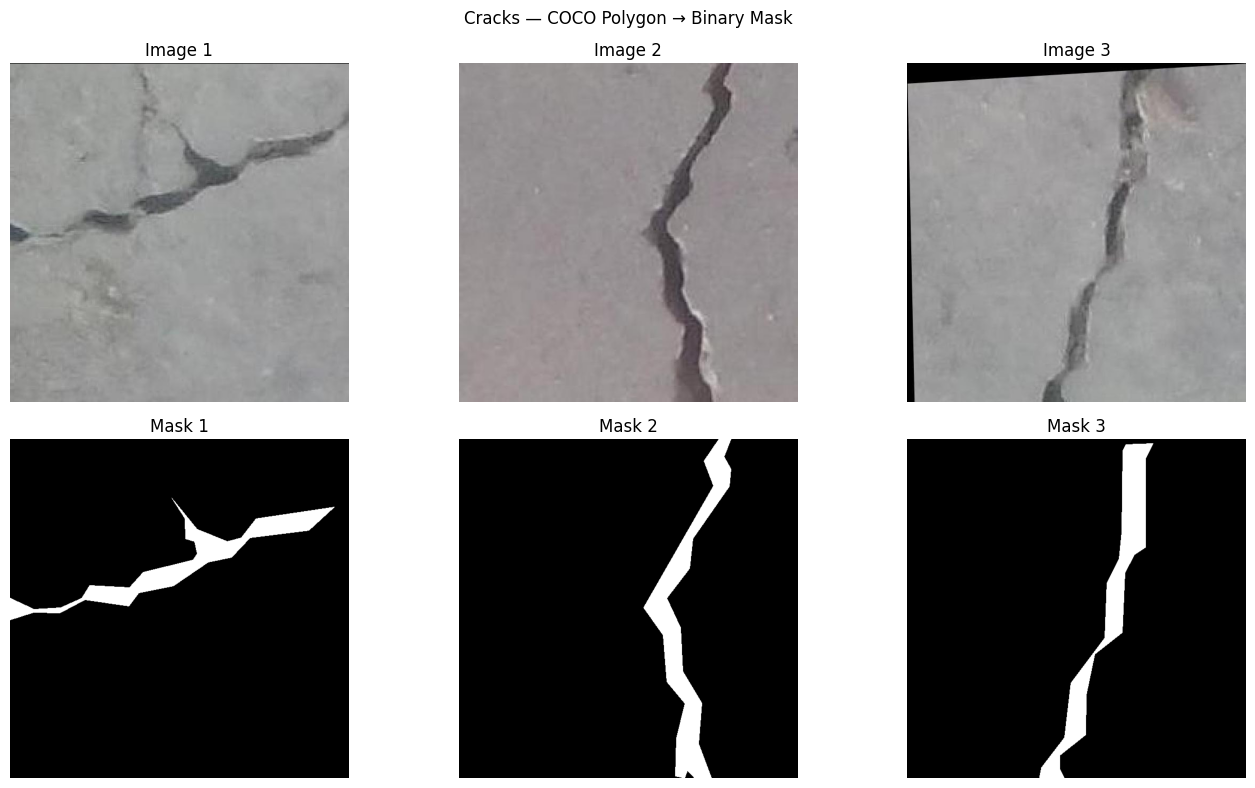

In [ ]:
def coco_to_masks(coco_data, mask_out, canon_map):
    Path(mask_out).mkdir(parents=True, exist_ok=True)

    img_info_by_fname = {info["file_name"]: info for info in coco_data["images"]}
    ann_idx = defaultdict(list)
    for ann in coco_data["annotations"]:
        ann_idx[ann["image_id"]].append(ann)

    records, skipped = [], 0
    seen_paths = set()  # ← track which canonical paths already processed

    for fname, cpath in canon_map.items():
        if not cpath.exists():
            skipped += 1
            continue

        # ← skip if we already wrote a mask for this canonical file
        if str(cpath) in seen_paths:
            continue
        seen_paths.add(str(cpath))

        info = img_info_by_fname.get(fname)
        if info is None:
            skipped += 1
            continue

        mask = np.zeros((info["height"], info["width"]), dtype=np.uint8)
        for ann in ann_idx[info["id"]]:
            for seg in ann["segmentation"]:
                if len(seg) < 6:
                    continue
                pts = np.array(seg, dtype=np.float32).reshape(-1, 2).astype(np.int32)
                cv2.fillPoly(mask, [pts], 255)

        mask_path = Path(mask_out) / (Path(fname).stem + ".png")
        cv2.imwrite(str(mask_path), mask)
        records.append({"img_path": cpath, "mask_path": mask_path, "filename": fname})

    if skipped:
        print(f"  WARNING: {skipped} files skipped")
    return records


ck_train_recs = coco_to_masks(
    ck_train_coco, CRACKS_ROOT / "train" / "masks", ck_train_map
)
ck_valid_recs = coco_to_masks(
    ck_valid_coco, CRACKS_ROOT / "valid" / "masks", ck_valid_map
)
ck_test_recs = coco_to_masks(ck_test_coco, CRACKS_ROOT / "test" / "masks", ck_test_map)
print(
    f"Crack masks — train:{len(ck_train_recs)}  valid:{len(ck_valid_recs)}  test:{len(ck_test_recs)}"
)
# Expected: train:907  valid:201  test:4

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, rec in enumerate(ck_train_recs[:3]):
    img = cv2.cvtColor(cv2.imread(str(rec["img_path"])), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(rec["mask_path"]), cv2.IMREAD_GRAYSCALE)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Image {i + 1}")
    axes[0, i].axis("off")
    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title(f"Mask {i + 1}")
    axes[1, i].axis("off")
plt.suptitle("Cracks — COCO Polygon → Binary Mask")
plt.tight_layout()
plt.show()

## Drywall Masks (YOLO BBox → Binary PNG)
Filled rectangle. Coarse but valid for baseline — SAM refinement can replace this later.

Drywall masks — train:160  valid:86


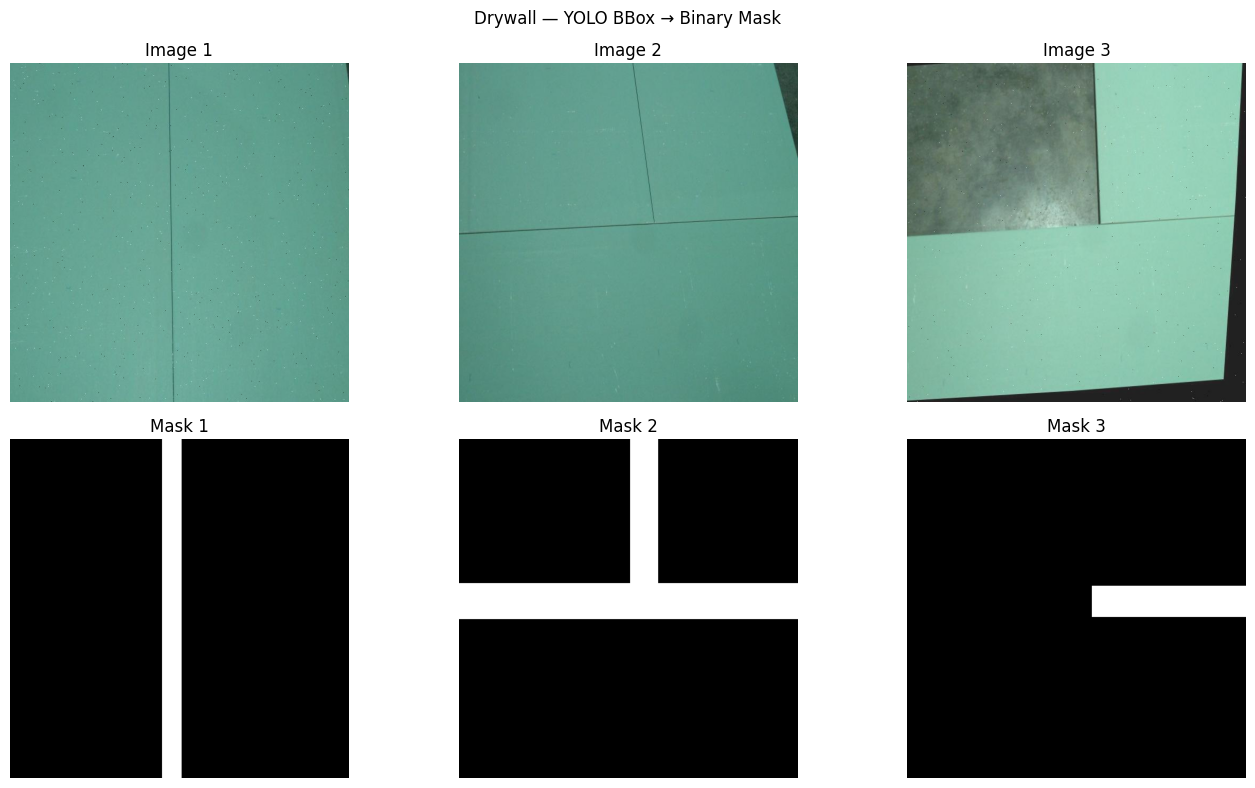

In [ ]:
def yolo_to_masks(canon_list, lbl_folder, mask_out):
    Path(mask_out).mkdir(parents=True, exist_ok=True)
    records, skipped = [], 0

    # ← iterate canon_list (deduplicated originals only), NOT img_folder
    for img_path in canon_list:
        lbl = Path(lbl_folder) / (img_path.stem + ".txt")
        if not lbl.exists():
            skipped += 1
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        H, W = img.shape[:2]
        mask = np.zeros((H, W), dtype=np.uint8)

        for line in open(lbl):
            p = line.strip().split()
            if len(p) < 5:
                continue
            cx, cy = float(p[1]) * W, float(p[2]) * H
            bw, bh = float(p[3]) * W, float(p[4]) * H
            x1, y1 = max(0, int(cx - bw / 2)), max(0, int(cy - bh / 2))
            x2, y2 = min(W, int(cx + bw / 2)), min(H, int(cy + bh / 2))
            mask[y1:y2, x1:x2] = 255

        mask_path = Path(mask_out) / (img_path.stem + ".png")
        cv2.imwrite(str(mask_path), mask)
        records.append(
            {"img_path": img_path, "mask_path": mask_path, "filename": img_path.name}
        )

    if skipped:
        print(f"  WARNING: {skipped} images had no label file")
    return records


dw_train_recs = yolo_to_masks(
    dw_train_canon, DRYWALL_ROOT / "train" / "labels", DRYWALL_ROOT / "train" / "masks"
)
dw_valid_recs = yolo_to_masks(
    dw_valid_canon, DRYWALL_ROOT / "valid" / "labels", DRYWALL_ROOT / "valid" / "masks"
)
print(f"Drywall masks — train:{len(dw_train_recs)}  valid:{len(dw_valid_recs)}")
# Expected: train:160  valid:86

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, rec in enumerate(dw_train_recs[:3]):
    img = cv2.cvtColor(cv2.imread(str(rec["img_path"])), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(rec["mask_path"]), cv2.IMREAD_GRAYSCALE)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Image {i + 1}")
    axes[0, i].axis("off")
    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title(f"Mask {i + 1}")
    axes[1, i].axis("off")
plt.suptitle("Drywall — YOLO BBox → Binary Mask")
plt.tight_layout()
plt.show()

## SStandardise Filenames & Copy to `processed/`
Rename to `{dataset}_{idx:05d}`, copy at **original resolution**. No resizing here — Dataset handles that at runtime.

In [ ]:
mapping_rows = []


def standardise(records, prefix, start_idx=1):
    img_out = OUT / prefix / "images"
    mask_out = OUT / prefix / "masks"
    out_recs, idx = [], start_idx

    for rec in records:
        if not rec["img_path"].exists() or not rec["mask_path"].exists():
            continue

        stem = f"{prefix}_{idx:05d}"
        new_img = img_out / f"{stem}.jpg"
        new_mask = mask_out / f"{stem}.png"

        shutil.copy2(rec["img_path"], new_img)
        shutil.copy2(rec["mask_path"], new_mask)

        mapping_rows.append(
            {"new_stem": stem, "original": rec["filename"], "dataset": prefix}
        )
        out_recs.append(
            {
                "stem": stem,
                "img": new_img,
                "mask": new_mask,
                "original": rec["filename"],
            }
        )
        idx += 1

    return idx, out_recs


all_dw = dw_train_recs + dw_valid_recs
all_ck = ck_train_recs + ck_valid_recs + ck_test_recs

_, dw_proc = standardise(all_dw, "drywall")
_, ck_proc = standardise(all_ck, "cracks")
print(
    f"Copied — drywall:{len(dw_proc)}  cracks:{len(ck_proc)}  total:{len(dw_proc) + len(ck_proc)}"
)

mapping_csv = OUT / "filename_mapping.csv"
with open(mapping_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["new_stem", "original", "dataset"])
    w.writeheader()
    w.writerows(mapping_rows)
print(f"Mapping saved → {mapping_csv}")


Copied — drywall:246  cracks:1112  total:1358
Mapping saved → ..\dataset\processed\filename_mapping.csv


## Train / Val / Test Split

In [ ]:
def make_split(records):
    rng = random.Random(SEED)
    r = records[:]
    rng.shuffle(r)
    n = len(r)
    n_tr = int(n * TRAIN_RATIO)
    n_va = int(n * VAL_RATIO)
    return r[:n_tr], r[n_tr : n_tr + n_va], r[n_tr + n_va :]


dw_tr, dw_va, dw_te = make_split(dw_proc)
ck_tr, ck_va, ck_te = make_split(ck_proc)

print(f"{'Dataset':<12} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>7}")
print("-" * 40)
for name, tr, va, te in [
    ("Drywall", dw_tr, dw_va, dw_te),
    ("Cracks", ck_tr, ck_va, ck_te),
]:
    print(
        f"{name:<12} {len(tr):>7} {len(va):>7} {len(te):>7} {len(tr) + len(va) + len(te):>7}"
    )
comb = [len(dw_tr) + len(ck_tr), len(dw_va) + len(ck_va), len(dw_te) + len(ck_te)]
print(f"{'Combined':<12} {comb[0]:>7} {comb[1]:>7} {comb[2]:>7} {sum(comb):>7}")

splits = {
    "seed": SEED,
    "ratios": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO},
    "drywall": {
        "train": [r["stem"] for r in dw_tr],
        "val": [r["stem"] for r in dw_va],
        "test": [r["stem"] for r in dw_te],
    },
    "cracks": {
        "train": [r["stem"] for r in ck_tr],
        "val": [r["stem"] for r in ck_va],
        "test": [r["stem"] for r in ck_te],
    },
}
splits_path = OUT / "splits.json"
with open(splits_path, "w") as f:
    json.dump(splits, f, indent=2)
print(f"\nSplits saved → {splits_path}")


Dataset        Train     Val    Test   Total
----------------------------------------
Drywall          172      36      38     246
Cracks           778     166     168    1112
Combined         950     202     206    1358

Splits saved → ..\dataset\processed\splits.json


## Prompt Assignment

In [ ]:
PROMPTS = {
    "drywall": {
        "pos": ["segment taping area", "segment drywall joint", "segment wall seam"],
        "neg": ["segment crack", "segment wall crack"],
    },
    "cracks": {
        "pos": ["segment crack", "segment wall crack", "segment surface crack"],
        "neg": ["segment taping area", "segment drywall joint"],
    },
}

rows = []
for ds, tr, va, te in [
    ("drywall", dw_tr, dw_va, dw_te),
    ("cracks", ck_tr, ck_va, ck_te),
]:
    for split, recs in [("train", tr), ("val", va), ("test", te)]:
        for rec in recs:
            rows.append(
                {
                    "stem": rec["stem"],
                    "dataset": ds,
                    "split": split,
                    "positive_prompts": ";".join(PROMPTS[ds]["pos"]),
                    "negative_prompts": ";".join(PROMPTS[ds]["neg"]),
                }
            )

prompts_csv = OUT / "prompts.csv"
with open(prompts_csv, "w", newline="") as f:
    w = csv.DictWriter(
        f,
        fieldnames=["stem", "dataset", "split", "positive_prompts", "negative_prompts"],
    )
    w.writeheader()
    w.writerows(rows)
print(f"Prompts saved → {prompts_csv}  ({len(rows)} rows)")


Prompts saved → ..\dataset\processed\prompts.csv  (1358 rows)


## Sanity Checks
Every image has a mask, dimensions match, pixel values are strictly {0, 255}.

In [ ]:
errors = []


def check_pair(img_path, mask_path):
    if not Path(img_path).exists():
        errors.append(f"MISSING IMG  : {img_path}")
        return
    if not Path(mask_path).exists():
        errors.append(f"MISSING MASK : {mask_path}")
        return
    img = cv2.imread(str(img_path))
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        errors.append(f"CORRUPT IMG  : {img_path}")
        return
    if mask is None:
        errors.append(f"CORRUPT MASK : {mask_path}")
        return
    if img.shape[:2] != mask.shape[:2]:
        errors.append(
            f"DIM MISMATCH : {img_path.name}  img={img.shape[:2]} mask={mask.shape[:2]}"
        )
    bad = set(np.unique(mask).tolist()) - {0, 255}
    if bad:
        errors.append(f"BAD VALS     : {mask_path.name}  {bad}")


for rec in dw_proc + ck_proc:
    check_pair(rec["img"], rec["mask"])

print(f"Checked {len(dw_proc) + len(ck_proc)} pairs")
if not errors:
    print("✓  All checks passed.")
else:
    print(f"✗  {len(errors)} issue(s):")
    for e in errors[:20]:
        print(f"   {e}")


Checked 1358 pairs
✓  All checks passed.
